In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [ ]:
list_c_vals=[np.float64(0.9930733865293206), np.float64(0.9920967260182538), np.float64(0.9909671201993773), np.float64(0.989884569072691), np.float64(0.9886490726381949), np.float64(0.9873606308958891), np.float64(0.9860192438457734), np.float64(0.9845249114878482), np.float64(0.9829776338221131), np.float64(0.9813774108485682), np.float64(0.9797242425672137), np.float64(0.9778181289780494), np.float64(0.9759590700810754), np.float64(0.9739470658762915), np.float64(0.971782116363698), np.float64(0.9695642215432947), np.float64(0.9670933814150816), np.float64(0.9646695959790589), np.float64(0.9621928652352263), np.float64(0.9591631891835839)]

## Simulaatio

In [5]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [ ]:
def center_truncate(arr, target_len):
    if len(arr) <= target_len:
        return arr
    extra = len(arr) - target_len
    start = int(extra / 2)
    end = extra-start
    return arr[start:-end]


def sim_pulse(f_1,f_2,f_supp,A,evolution,dim,f_rabi,K=20,t_ramp=5,verbose=False,p=1):
    T_floquet = 10*np.pi/(2*f_1-f_2) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    t_gap1=np.pi/(f_supp/2+2*f_1-f_2/2)
    t_gap2=np.pi/(2*f_2-f_supp-2*f_1)

    t_ramp_new1=t_ramp-t_gap1/2
    t_ramp_new2=t_ramp-t_gap2/2

    phi1=t_gap1*f_1
    phi2=t_gap2*f_2

    N_edge1 = int((t_ramp_new1*2+t_gap1/2)/dt)
    N_edge2 = int((t_ramp_new1*2-t_gap2/2)/dt)

    N_edge3 = int((t_ramp_new2*2+t_gap1/2)/dt)
    N_edge4 = int((t_ramp_new2*2-t_gap2/2)/dt)

    N_pulse = int(1/(f_rabi*dt))

    N_edge=max(N_edge1,N_edge2,N_edge3,N_edge4)

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse1 = pulses.Pulse(f_1,f_ef,[pulses.gaussian(t_ramp_new1*2-t_gap1/2,t_ramp_new1/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new1/2)],[N_edge2,N_pulse,N_edge1],time_unit=dt,offset_input=-phi1/2)
    pulse2 = pulses.Pulse(f_1,f_ef,[pulses.gaussian(t_ramp_new1*2+t_gap1/2,t_ramp_new1/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new1/2)],[N_edge1,N_pulse,N_edge2],time_unit=dt,offset_input=phi1/2)

    combined_pulse1 = (pulse1.raw + pulse2.raw)/2
    m_1 =  2*np.abs(np.cos(phi1/2))

    pulse1 = pulses.Pulse(f_2,f_ef,[pulses.gaussian(t_ramp_new2*2-t_gap1/2,t_ramp_new2/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new2/2)],[N_edge4,N_pulse,N_edge3],time_unit=dt,offset_input=-phi2/2)
    pulse2 = pulses.Pulse(f_2,f_ef,[pulses.gaussian(t_ramp_new2*2+t_gap1/2,t_ramp_new2/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new2/2)],[N_edge3,N_pulse,N_edge4],time_unit=dt,offset_input=phi2/2)

    combined_pulse2 = (pulse1.raw + pulse2.raw)/2
    m_2 =  2*np.abs(np.cos(phi2/2))

    pulse_length=min(len(combined_pulse1),len(combined_pulse2))

    combined_pulse = center_truncate(combined_pulse1,pulse_length)/m_1-center_truncate(combined_pulse2,pulse_length)/m_2
    

    if verbose:
        plt.figure()
        plt.plot(pulse1.time_vals,combined_pulse)
        plt.xlabel("Aika (ms)")
        plt.ylabel("Normalisoitu amplitudi")
        plt.title("Yhdistetty pulssi")
        plt.show()

    U_floquet=evolution.U_floquet(A*combined_pulse[N_edge:N_edge+K],dt)
    U_floquet=np.linalg.matrix_power(U_floquet,p)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim, dtype=complex)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge): #Aikakehitys nousevalle rampille
        psi_eig_accum = evolution.U(A*combined_pulse[i], dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä/K koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (K*dt)
    N_sim=int(N_pulse/(K*p))

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse1 = pulses.Pulse(f_1,f_ef,[pulses.gaussian(t_ramp_new1*2-t_gap1/2,t_ramp_new1/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new1/2)],[N_edge2,K*p*k,N_edge1],time_unit=dt,offset_input=-phi1/2)
        pulse2 = pulses.Pulse(f_1,f_ef,[pulses.gaussian(t_ramp_new1*2+t_gap1/2,t_ramp_new1/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new1/2)],[N_edge1,K*p*k,N_edge2],time_unit=dt,offset_input=phi1/2)

        combined_pulse1 = pulse1.raw + pulse2.raw

        pulse1 = pulses.Pulse(f_2,f_ef,[pulses.gaussian(t_ramp_new2*2-t_gap1/2,t_ramp_new2/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new2/2)],[N_edge4,K*p*k,N_edge3],time_unit=dt,offset_input=-phi2/2)
        pulse2 = pulses.Pulse(f_2,f_ef,[pulses.gaussian(t_ramp_new2*2+t_gap1/2,t_ramp_new2/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new2/2)],[N_edge3,K*p*k,N_edge4],time_unit=dt,offset_input=phi2/2)

        combined_pulse2 = pulse1.raw + pulse2.raw

        pulse_length=min(len(combined_pulse1),len(combined_pulse2))

        combined_pulse = center_truncate(combined_pulse1,pulse_length)/m_1-center_truncate(combined_pulse2,pulse_length)/m_2

        remainder = len(combined_pulse)-N_edge-K*p*k

        for i in range(0, remainder): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*combined_pulse[N_edge+K*p*k+i], dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla


    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*p*dt + 2*t_ramp

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    index = np.argmax(e_vals)
    T_pulse = pulse_times[index]
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(f_1,f_2,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range, max_range):
        delta = AC_stark+i/scale
        AC_stark_vals.append(delta)
        if A < 2.3:
            sim_vals = sim_pulse(f_1,f_2,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,p=10,K=200)
        elif A < 2.9:
            sim_vals = sim_pulse(f_1,f_2,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,p=5,K=200)
        else:
            sim_vals = sim_pulse(f_1,f_2,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,p=1,K=200)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    delta=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(delta,pi_pulse,[e_max,f_max],max_e_vals)

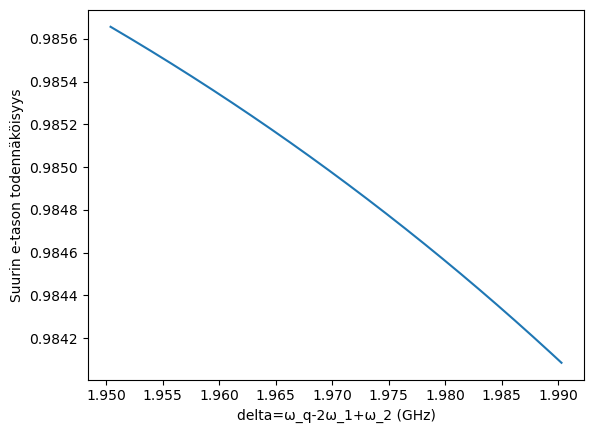

Amplitudi (GHz): 2.039088111159714
AC-stark siirtymä (GHz): 1.9503907245311676
E-tason suurin todennäköisyys: 0.9863813630252642
Pulssin pituus (ns): 196.17175076443056
Rabi-taajuus (fourier):  0.0025443398828304755


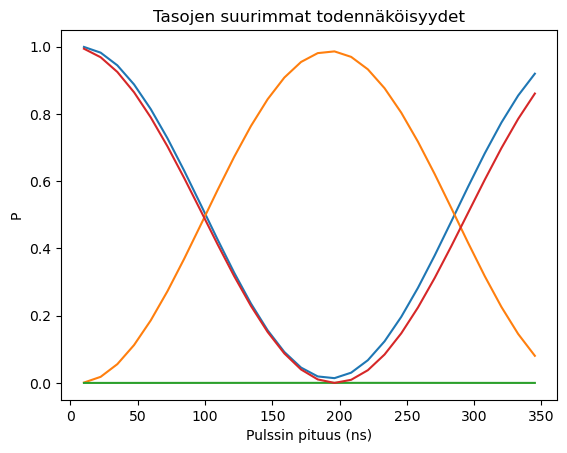

---------------------------------------------


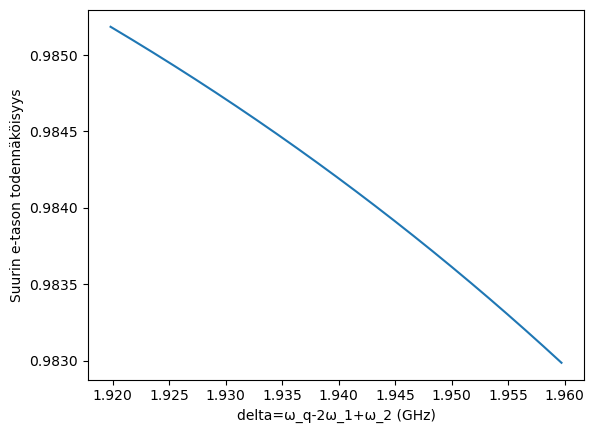

Amplitudi (GHz): 2.1732386447886425
AC-stark siirtymä (GHz): 1.9198217272532792
E-tason suurin todennäköisyys: 0.9851846377827145
Pulssin pituus (ns): 159.0840206678187
Rabi-taajuus (fourier):  0.0030958278390333842


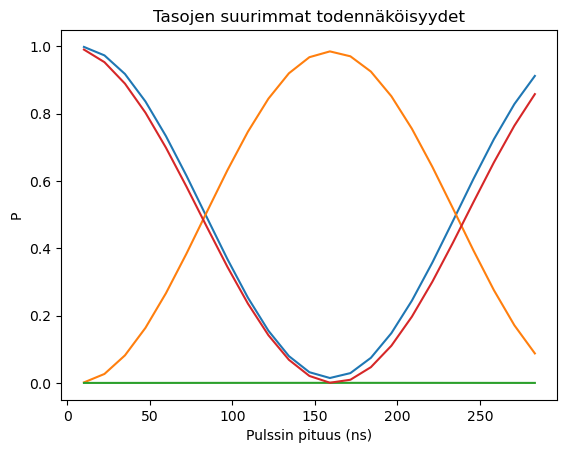

---------------------------------------------


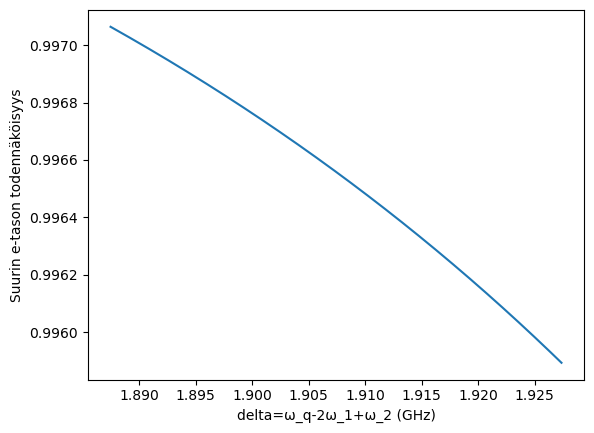

Amplitudi (GHz): 2.307389178417571
AC-stark siirtymä (GHz): 1.8874574125358596
E-tason suurin todennäköisyys: 0.9970639314741054
Pulssin pituus (ns): 134.37830158652045
Rabi-taajuus (fourier):  0.004133669707035457


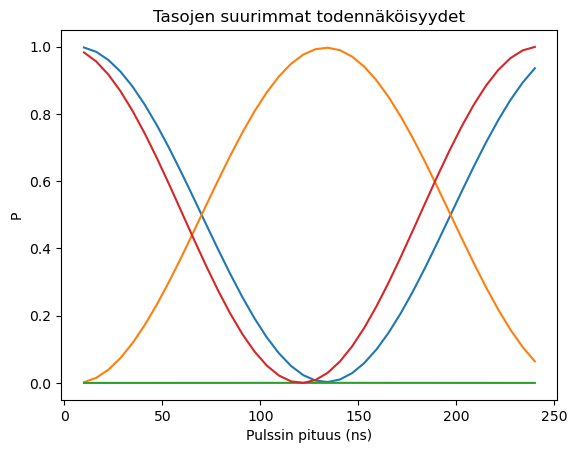

---------------------------------------------


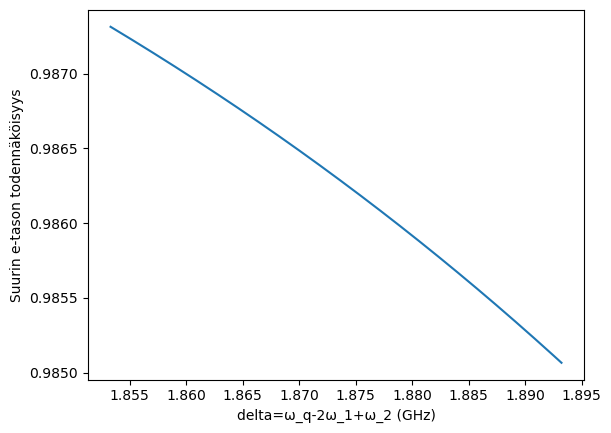

Amplitudi (GHz): 2.4415397120464997
AC-stark siirtymä (GHz): 1.853297780378909
E-tason suurin todennäköisyys: 0.9890048228721336
Pulssin pituus (ns): 115.83717486964673
Rabi-taajuus (fourier):  0.004912051710387022


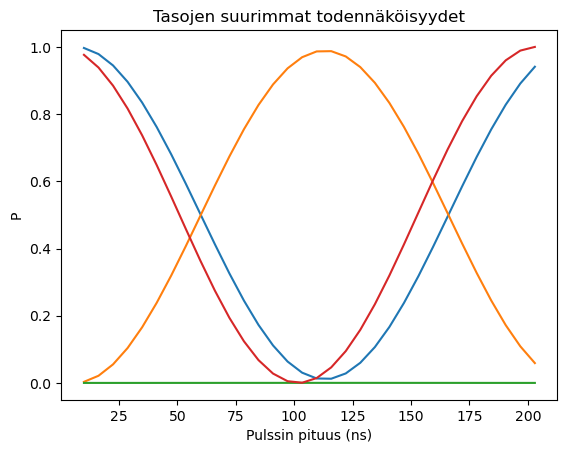

---------------------------------------------


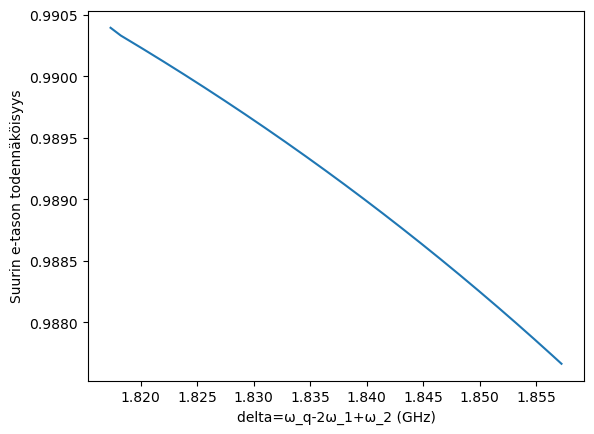

Amplitudi (GHz): 2.575690245675428
AC-stark siirtymä (GHz): 1.8173428307824273
E-tason suurin todennäköisyys: 0.9903941606705672
Pulssin pituus (ns): 97.26894863382229
Rabi-taajuus (fourier):  0.005791466155683614


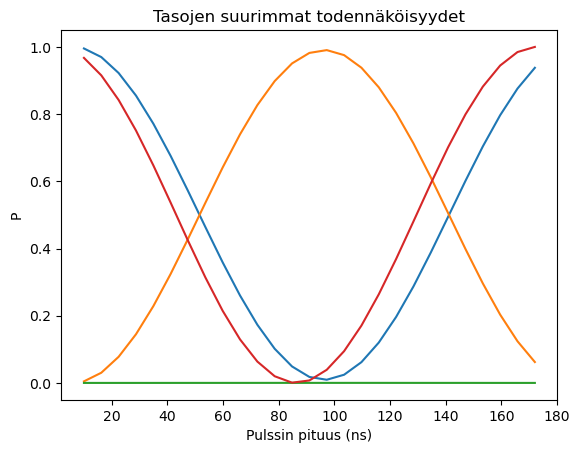

---------------------------------------------


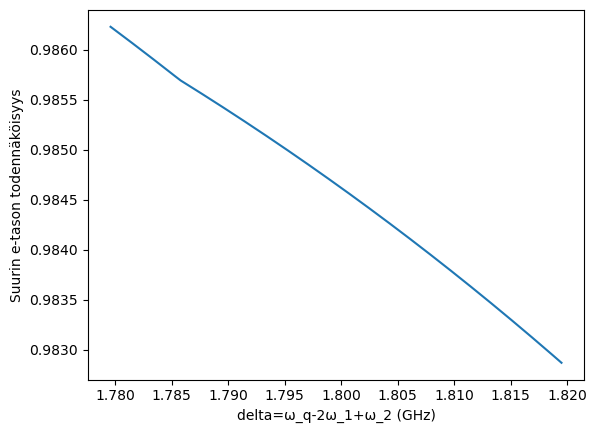

Amplitudi (GHz): 2.7098407793043564
AC-stark siirtymä (GHz): 1.779592563746414
E-tason suurin todennäköisyys: 0.987911052774246
Pulssin pituus (ns): 84.89956768479678
Rabi-taajuus (fourier):  0.006760107295343253


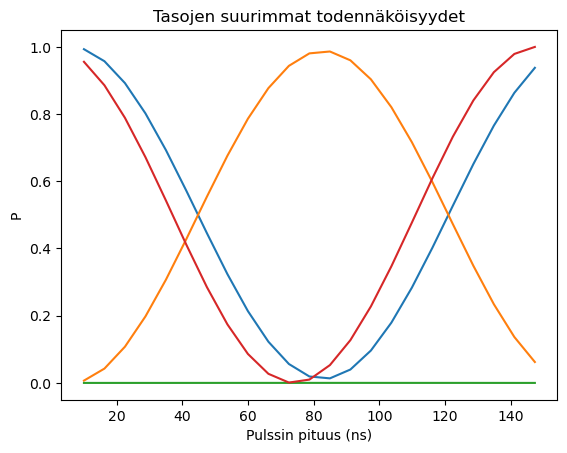

---------------------------------------------


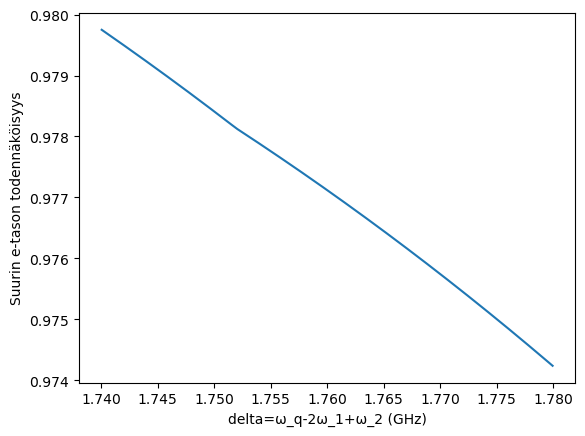

Amplitudi (GHz): 2.8439913129332854
AC-stark siirtymä (GHz): 1.74004697927087
E-tason suurin todennäköisyys: 0.979908659492383
Pulssin pituus (ns): 72.50121795683864
Rabi-taajuus (fourier):  0.007881619807450875


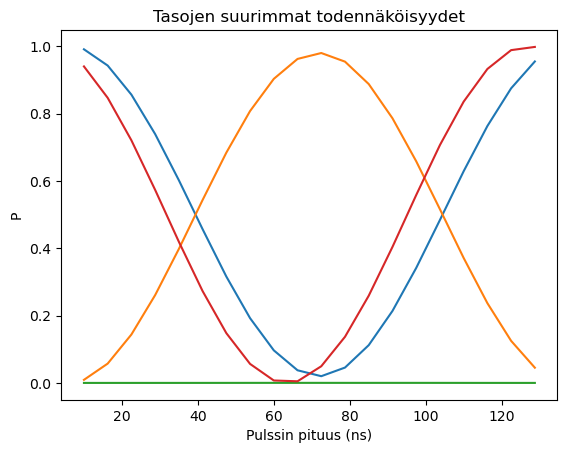

---------------------------------------------


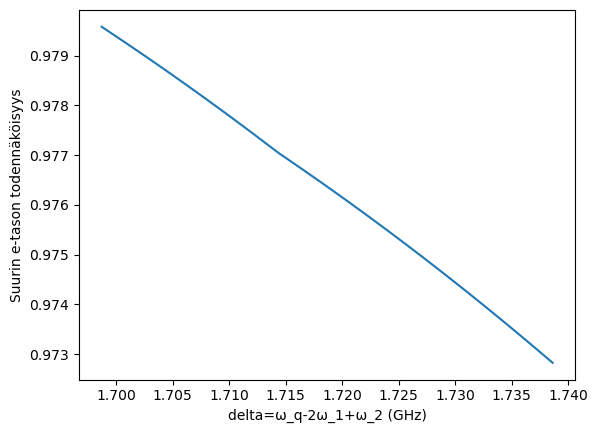

Amplitudi (GHz): 2.9781418465622136
AC-stark siirtymä (GHz): 1.698706077355795
E-tason suurin todennäköisyys: 0.9796556212016826
Pulssin pituus (ns): 62.58071022695719
Rabi-taajuus (fourier):  0.009149736743394863


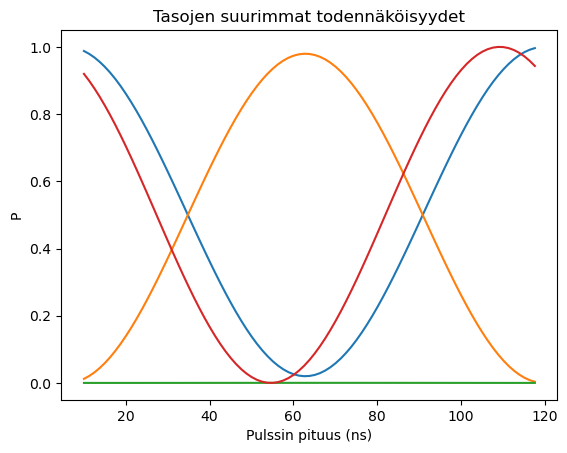

---------------------------------------------


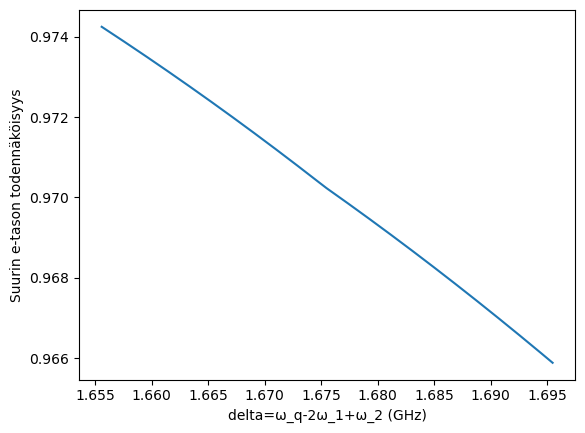

Amplitudi (GHz): 3.1122923801911426
AC-stark siirtymä (GHz): 1.6555698580011884
E-tason suurin todennäköisyys: 0.9743444462915922
Pulssin pituus (ns): 55.14012233353014
Rabi-taajuus (fourier):  0.010563134688245997


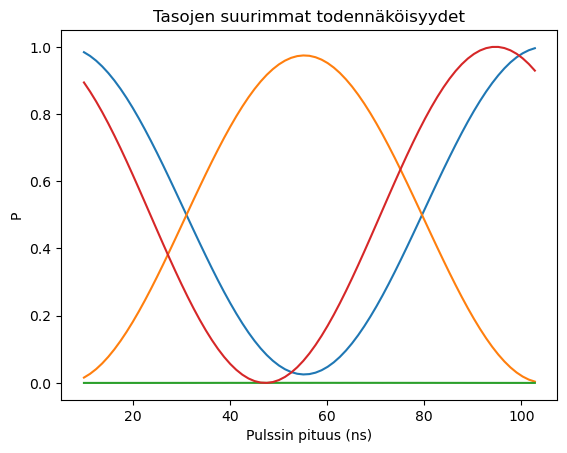

---------------------------------------------


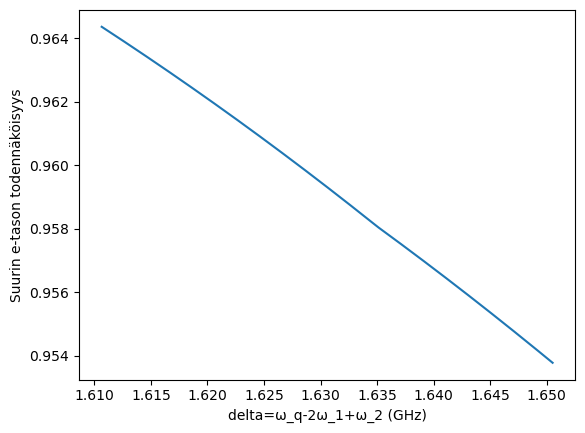

Amplitudi (GHz): 3.2464429138200708
AC-stark siirtymä (GHz): 1.610638321207051
E-tason suurin todennäköisyys: 0.9644139030529182
Pulssin pituus (ns): 48.934042960996834
Rabi-taajuus (fourier):  0.012137475064769306


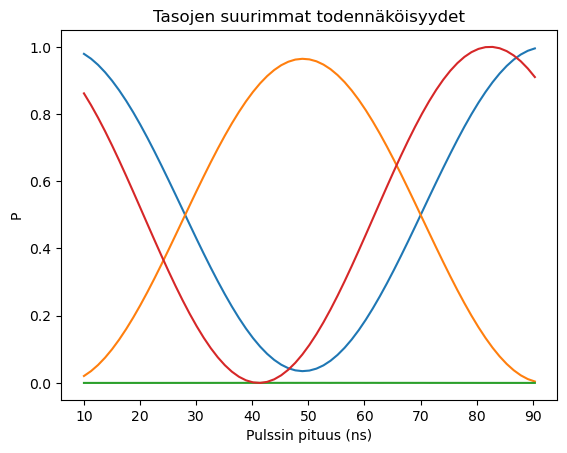

---------------------------------------------


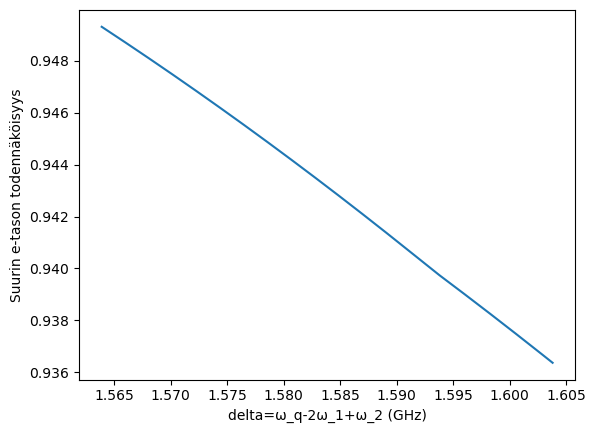

Amplitudi (GHz): 3.380593447449
AC-stark siirtymä (GHz): 1.5639114669733822
E-tason suurin todennäköisyys: 0.9494954738712945
Pulssin pituus (ns): 43.967515077700604
Rabi-taajuus (fourier):  0.013896452859392554


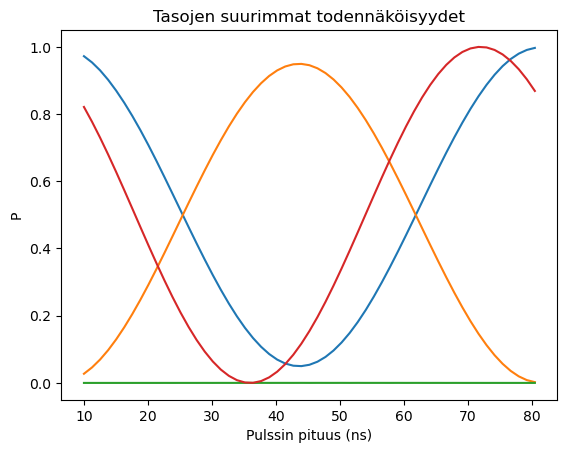

---------------------------------------------


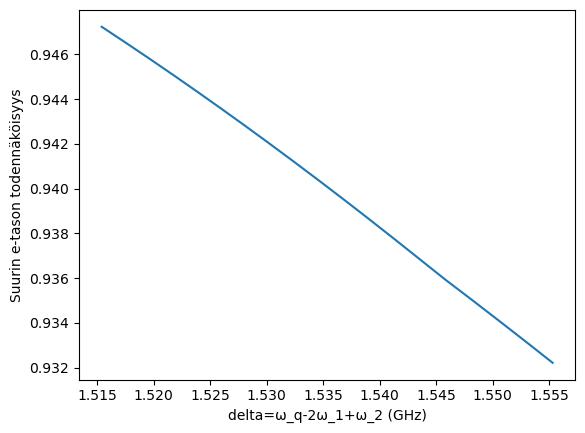

Amplitudi (GHz): 3.514743981077928
AC-stark siirtymä (GHz): 1.5153892953001828
E-tason suurin todennäköisyys: 0.9472476408130339
Pulssin pituus (ns): 38.99169574354217
Rabi-taajuus (fourier):  0.01586661242823175


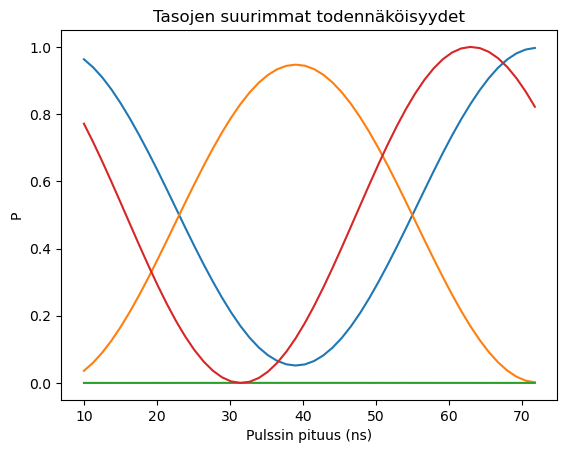

---------------------------------------------


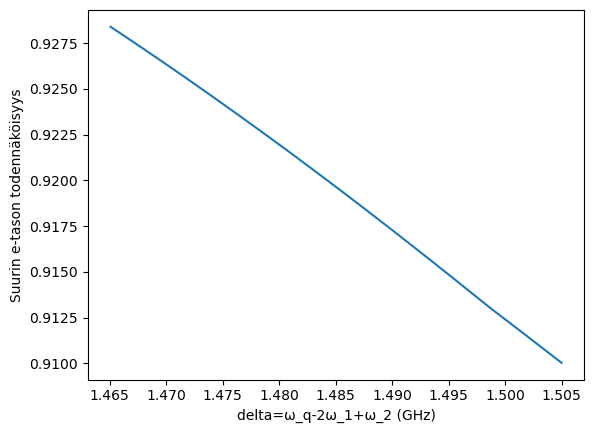

Amplitudi (GHz): 3.648894514706856
AC-stark siirtymä (GHz): 1.465071806187452
E-tason suurin todennäköisyys: 0.9283906714019945
Pulssin pituus (ns): 35.258191888773524
Rabi-taajuus (fourier):  0.018036954806972386


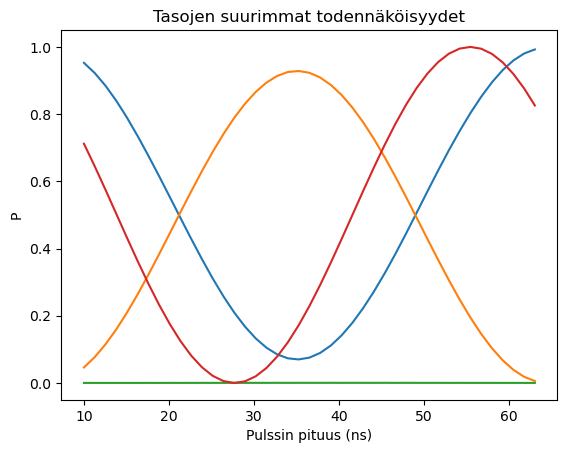

---------------------------------------------


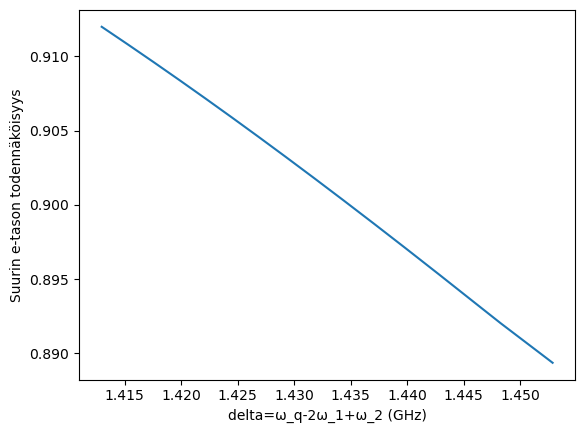

Amplitudi (GHz): 3.783045048335785
AC-stark siirtymä (GHz): 1.41295899963519
E-tason suurin todennäköisyys: 0.9119943256644774
Pulssin pituus (ns): 31.513815259240882
Rabi-taajuus (fourier):  0.018376509812200195


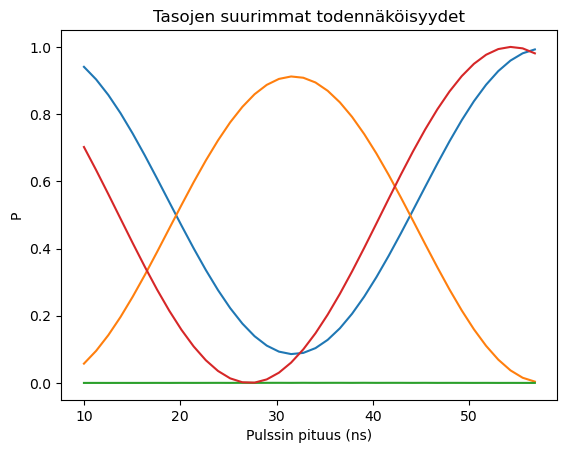

---------------------------------------------


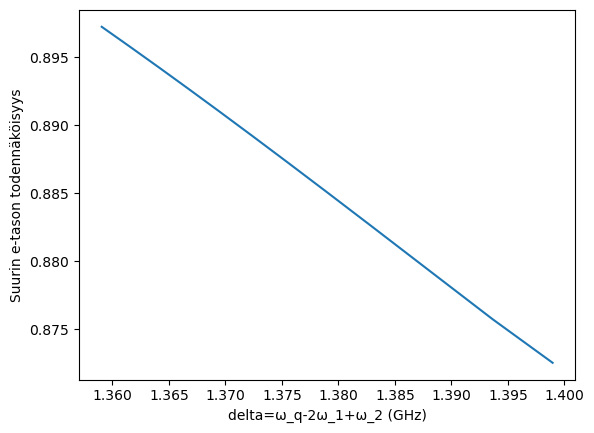

Amplitudi (GHz): 3.9171955819647133
AC-stark siirtymä (GHz): 1.3590508756433968
E-tason suurin todennäköisyys: 0.8978342337912807
Pulssin pituus (ns): 29.02506826319615
Rabi-taajuus (fourier):  0.02074824839755653


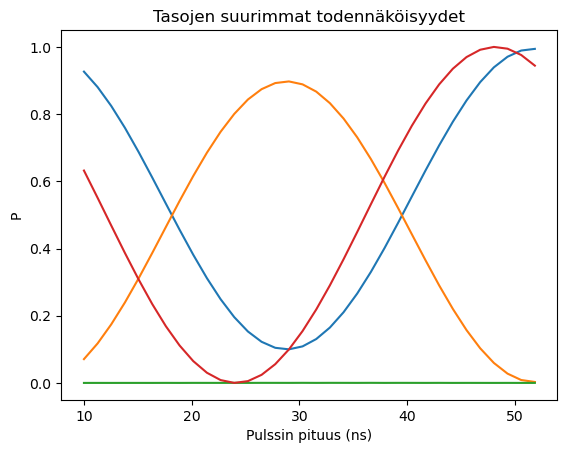

---------------------------------------------


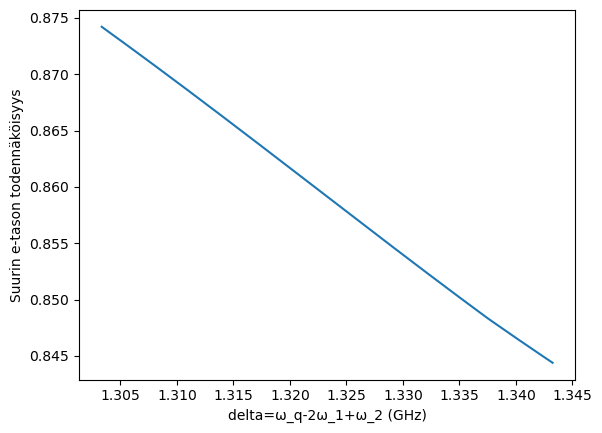

Amplitudi (GHz): 4.051346115593642
AC-stark siirtymä (GHz): 1.3033474342120726
E-tason suurin todennäköisyys: 0.8755265320302368
Pulssin pituus (ns): 26.52610997598307
Rabi-taajuus (fourier):  0.023365366345894485


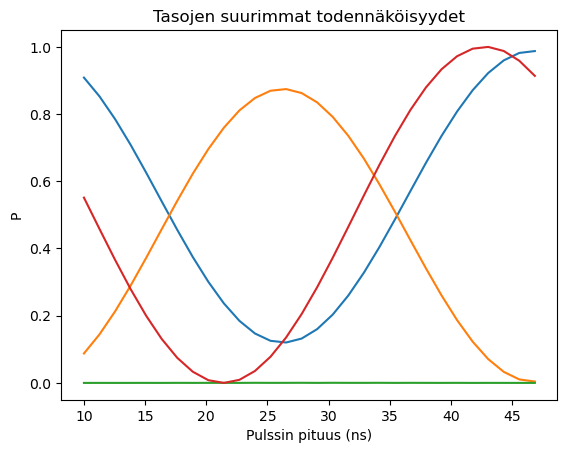

---------------------------------------------


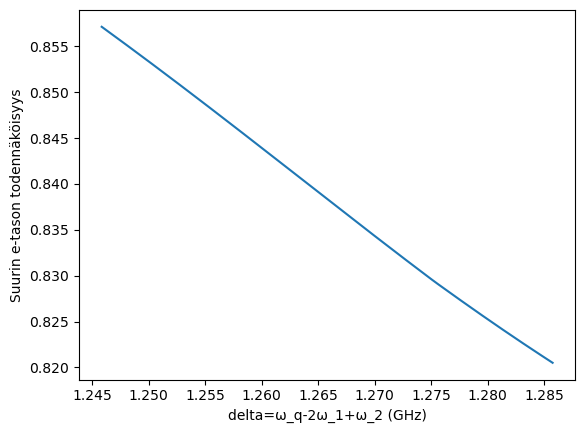

Amplitudi (GHz): 4.1854966492225705
AC-stark siirtymä (GHz): 1.2458486753412172
E-tason suurin todennäköisyys: 0.8571228721347998
Pulssin pituus (ns): 24.019358489864427
Rabi-taajuus (fourier):  0.02625153925859202


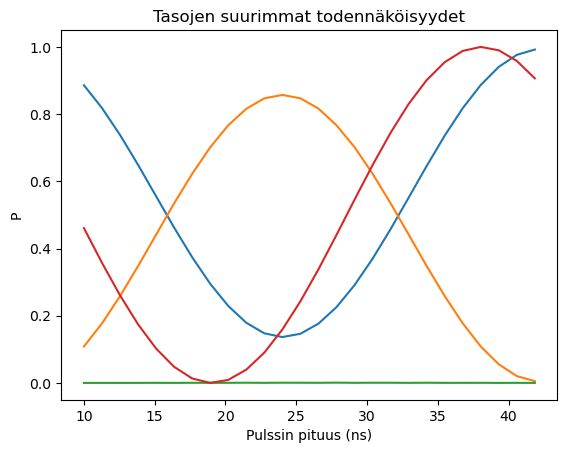

---------------------------------------------


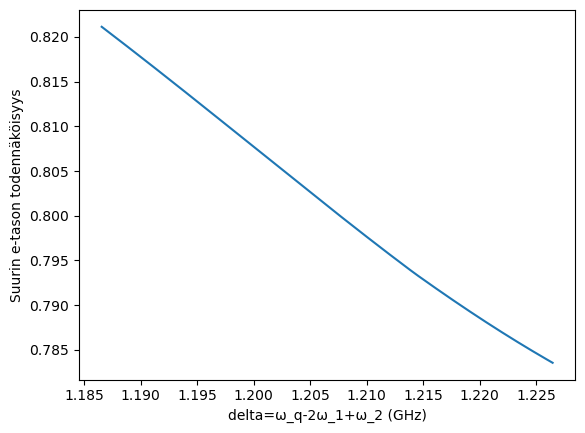

Amplitudi (GHz): 4.3196471828515
AC-stark siirtymä (GHz): 1.1865545990308304
E-tason suurin todennäköisyys: 0.8310053835745572
Pulssin pituus (ns): 22.77689354492307
Rabi-taajuus (fourier):  0.029349857121491584


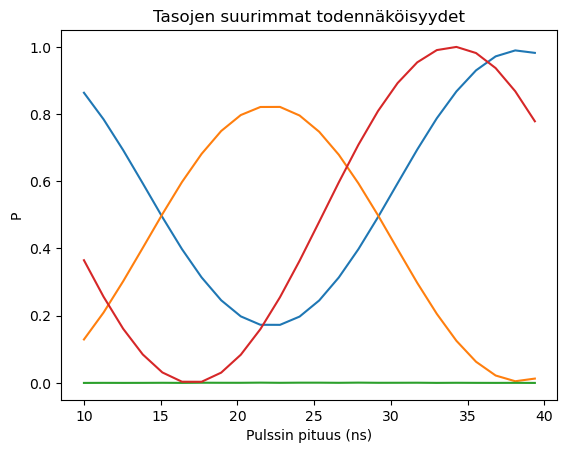

---------------------------------------------


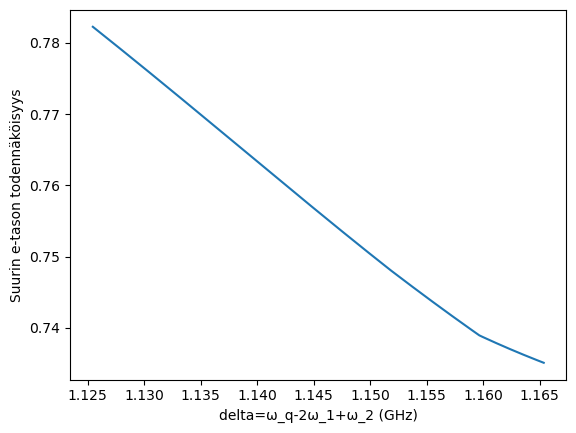

Amplitudi (GHz): 4.453797716480428
AC-stark siirtymä (GHz): 1.125465205280913
E-tason suurin todennäköisyys: 0.7876413973123134
Pulssin pituus (ns): 20.247825507070402
Rabi-taajuus (fourier):  0.032678515134667574


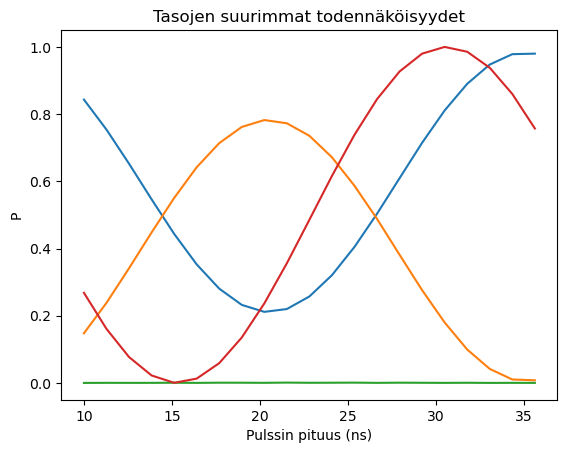

---------------------------------------------


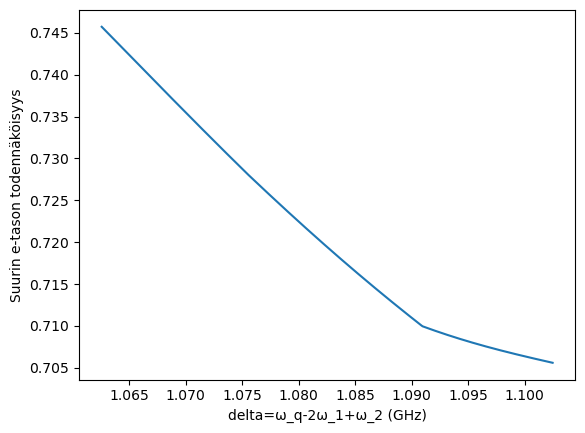

Amplitudi (GHz): 4.587948250109356
AC-stark siirtymä (GHz): 1.0625804940914645
E-tason suurin todennäköisyys: 0.7517844790580462
Pulssin pituus (ns): 18.99517059348125
Rabi-taajuus (fourier):  0.040321003003653676


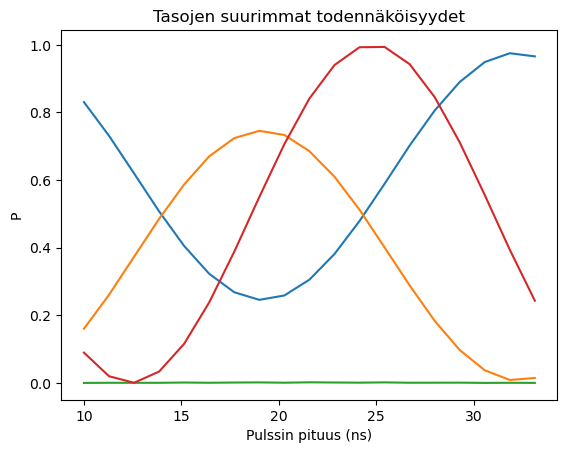

---------------------------------------------


In [ ]:
c_vals = [] #c:n arvot
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.08
max_range = 0.18
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    
    f_1_opt=f_1*list_c_vals[i]
    f_2_opt=f_2*list_c_vals[i]

    f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
    AC_stark=-0.04988*A**2 - 0.01776*A + 2.214

    params=find_params(f_1_opt,f_2_opt, A, evolution_eigenbasis,f_rabi,AC_stark,[-200,200],10000)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])

    m=10

    if A < 2.3:
        vals = sim_pulse(f_1_opt,f_2_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,p=10,K=200)
    elif A < 2.9:
        vals = sim_pulse(f_1_opt,f_2_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,p=5,K=200)
    else:
        vals = sim_pulse(f_1_opt,f_2_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,p=1,K=200)
    
    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 
    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(2.039088111159714), np.float64(2.1732386447886425), np.float64(2.307389178417571), np.float64(2.4415397120464997), np.float64(2.575690245675428), np.float64(2.7098407793043564), np.float64(2.8439913129332854), np.float64(2.9781418465622136), np.float64(3.1122923801911426), np.float64(3.2464429138200708), np.float64(3.380593447449), np.float64(3.514743981077928), np.float64(3.648894514706856), np.float64(3.783045048335785), np.float64(3.9171955819647133), np.float64(4.051346115593642), np.float64(4.1854966492225705), np.float64(4.3196471828515), np.float64(4.453797716480428), np.float64(4.587948250109356)]


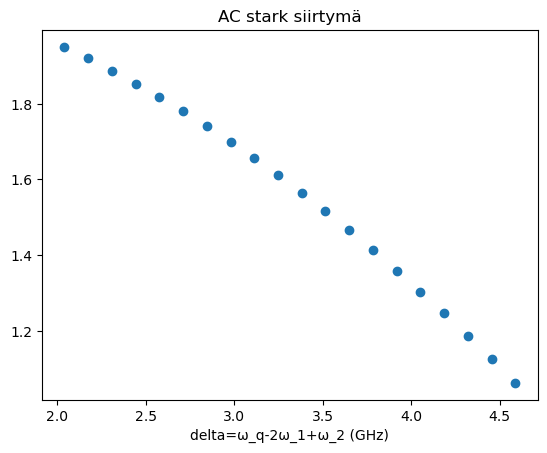

[np.float64(1.9503907245311676), np.float64(1.9198217272532792), np.float64(1.8874574125358596), np.float64(1.853297780378909), np.float64(1.8173428307824273), np.float64(1.779592563746414), np.float64(1.74004697927087), np.float64(1.698706077355795), np.float64(1.6555698580011884), np.float64(1.610638321207051), np.float64(1.5639114669733822), np.float64(1.5153892953001828), np.float64(1.465071806187452), np.float64(1.41295899963519), np.float64(1.3590508756433968), np.float64(1.3033474342120726), np.float64(1.2458486753412172), np.float64(1.1865545990308304), np.float64(1.125465205280913), np.float64(1.0625804940914645)]
[]


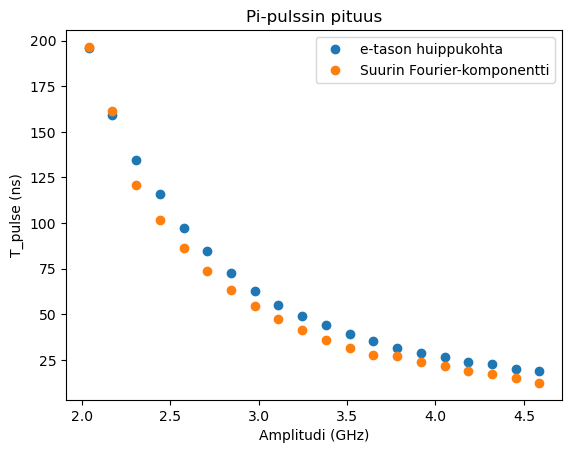

[np.float64(196.17175076443056), np.float64(159.0840206678187), np.float64(134.37830158652045), np.float64(115.83717486964673), np.float64(97.26894863382229), np.float64(84.89956768479678), np.float64(72.50121795683864), np.float64(62.58071022695719), np.float64(55.14012233353014), np.float64(48.934042960996834), np.float64(43.967515077700604), np.float64(38.99169574354217), np.float64(35.258191888773524), np.float64(31.513815259240882), np.float64(29.02506826319615), np.float64(26.52610997598307), np.float64(24.019358489864427), np.float64(22.77689354492307), np.float64(20.247825507070402), np.float64(18.99517059348125)]


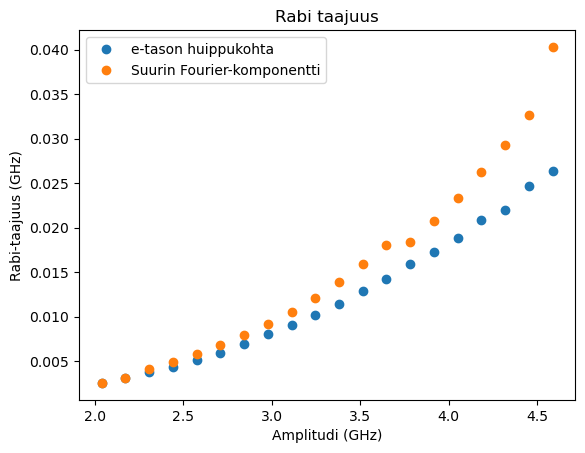

[np.float64(0.0025443398828304755), np.float64(0.0030958278390333842), np.float64(0.004133669707035457), np.float64(0.004912051710387022), np.float64(0.005791466155683614), np.float64(0.006760107295343253), np.float64(0.007881619807450875), np.float64(0.009149736743394863), np.float64(0.010563134688245997), np.float64(0.012137475064769306), np.float64(0.013896452859392554), np.float64(0.01586661242823175), np.float64(0.018036954806972386), np.float64(0.018376509812200195), np.float64(0.02074824839755653), np.float64(0.023365366345894485), np.float64(0.02625153925859202), np.float64(0.029349857121491584), np.float64(0.032678515134667574), np.float64(0.040321003003653676)]


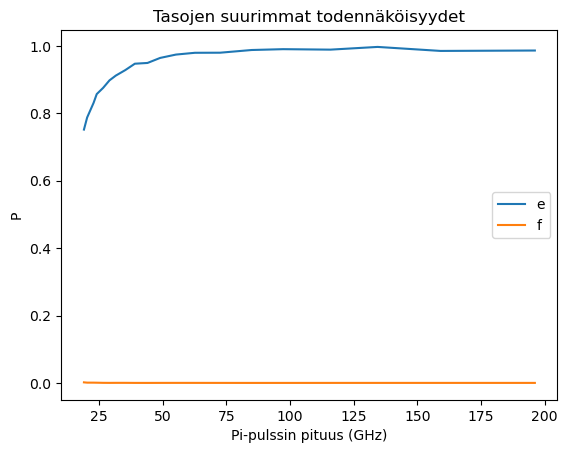

[np.float64(0.9863813630252642), np.float64(0.9851846377827145), np.float64(0.9970639314741054), np.float64(0.9890048228721336), np.float64(0.9903941606705672), np.float64(0.987911052774246), np.float64(0.979908659492383), np.float64(0.9796556212016826), np.float64(0.9743444462915922), np.float64(0.9644139030529182), np.float64(0.9494954738712945), np.float64(0.9472476408130339), np.float64(0.9283906714019945), np.float64(0.9119943256644774), np.float64(0.8978342337912807), np.float64(0.8755265320302368), np.float64(0.8571228721347998), np.float64(0.8310053835745572), np.float64(0.7876413973123134), np.float64(0.7517844790580462)]
[np.float64(0.00019175368331344073), np.float64(0.00021757666635676337), np.float64(0.00020643544173789172), np.float64(0.00019225385102741312), np.float64(0.00015267816037457525), np.float64(0.00013742570546373777), np.float64(0.00020100385319643502), np.float64(0.00025508033459995867), np.float64(0.0002703802482292025), np.float64(0.00023384245211415265), n

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """

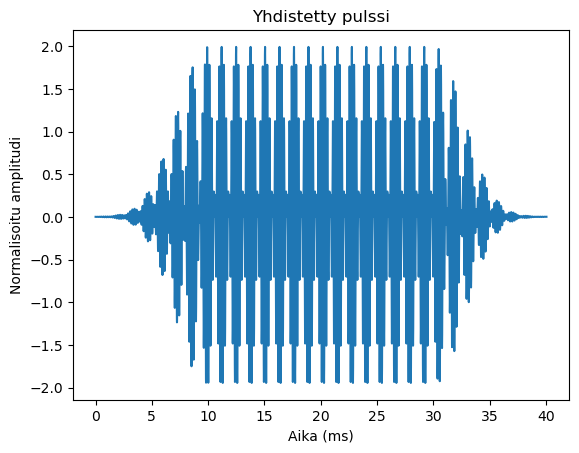

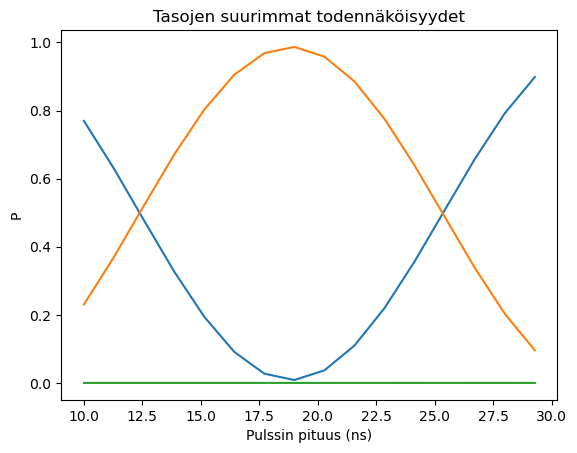

---------------------------------------------


In [9]:
A=4.587948250109356
c=list_c_vals[-1]
vals = sim_pulse(f_1*c,f_2*c,f_ef,A,evolution_eigenbasis,dim,0.05,t_ramp=5,p=1,K=200,verbose=True)
    
g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.plot(vals[4][:n_picked], g_vals[:n_picked])
plt.plot(vals[4][:n_picked], e_vals[:n_picked])
plt.plot(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")